In [3]:
import os
import re
import glob
import math
import uuid
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import HTML, display
from sklearn.metrics import mean_squared_error


--- Los 5 menores valores de Chi cuadrado ---
    Período (h) | Chi cuadrado ($\chi^2$)
----------------------------------------
       3.249145 |            29.591985
       3.249444 |            29.705974
       3.170195 |            29.787811
       3.251462 |            29.866786
       3.174997 |            29.895743


Por favor, ingresa el nombre del asteroide:  atira


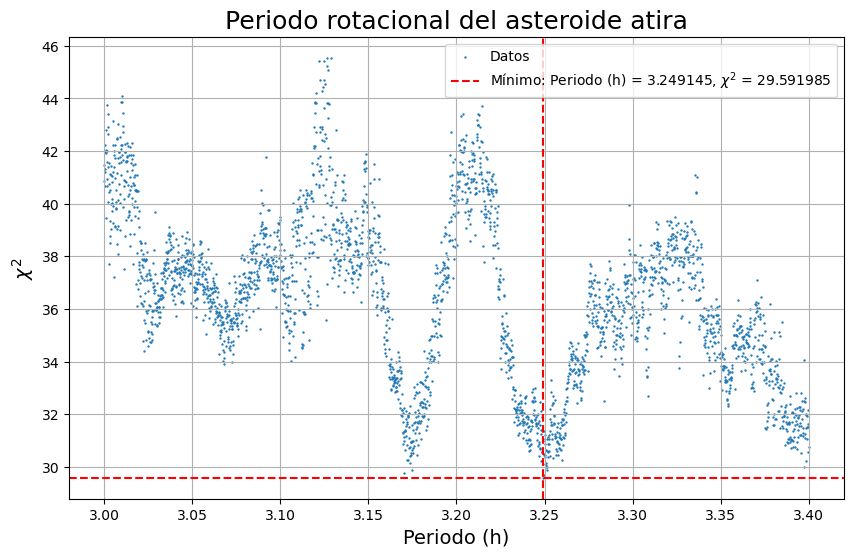

In [19]:
##################################
# PERIODO ROTACIONAL
##################################


df = np.loadtxt('C:/Users/HP/Desktop/Maestria/TESIS/DAMIT/version_0.2.1/convexinv/Atira/out_periods_atira')
nombre_asteroide = input("Por favor, ingresa el nombre del asteroide: ")

n_mejores = 5
df_ordenado = sorted(df, key=lambda fila: fila[2])

print(f"\n--- Los {n_mejores} menores valores de Chi cuadrado ---")
print(f"{'Período (h)':>15} | {'Chi cuadrado ($\\chi^2$)':>20}")
print("-" * 40)

for fila in df_ordenado[:n_mejores]:
    periodo = fila[0]
    chi2 = fila[2]
    print(f"{periodo:15.6f} | {chi2:20.6f}")


x = [fila[0] for fila in df]  # Primer dato (eje x)
y = [fila[2] for fila in df]  # Tercer dato (eje y)


min_index = y.index(min(y))
min_x = x[min_index]
min_y = y[min_index]


plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=0.5, label='Datos')
plt.axvline(x=min_x, color='red', linestyle='--', linewidth=1.5,
            label=f'Mínimo: Periodo (h) = {min_x:.6f}, $\\chi^2$ = {min_y:.6f}')
plt.axhline(y=min_y, color='red', linestyle='--', linewidth=1.5)

plt.xlabel('Periodo (h)',fontsize=14)
plt.ylabel(r'$\chi^2$',fontsize=14)
plt.title(f'Periodo rotacional del asteroide {nombre_asteroide}',fontsize=18)
plt.grid(True)
plt.legend()
plt.show()

Introduce el período rotacional del asteroide [horas]:  2.822368



                       MEJOR SOLUCIÓN
Archivo : out_lcs_30_285
Beta    : 30.0°
Lambda  : 285.0°
RMS     : 0.04326952

             20 MEJORES SOLUCIONES
  N       Beta     Lambda             RMS
-----------------------------------------------------------------
  1       30.0      285.0      0.04326952
  2       15.0      285.0      0.04371211
  3       45.0      210.0      0.04422502
  4       45.0      195.0      0.04428072
  5       30.0      180.0      0.04430820
  6       30.0       90.0      0.04437318
  7        0.0      285.0      0.04452333
  8        0.0      315.0      0.04469400
  9       30.0      195.0      0.04472971
 10       45.0      180.0      0.04474339
 11       15.0      255.0      0.04476596
 12       15.0       60.0      0.04476989
 13        0.0      270.0      0.04485082
 14        0.0      300.0      0.04487180
 15        0.0       30.0      0.04492710
 16      -30.0      345.0      0.04495080
 17       15.0      105.0      0.04495717
 18       15.0      315.

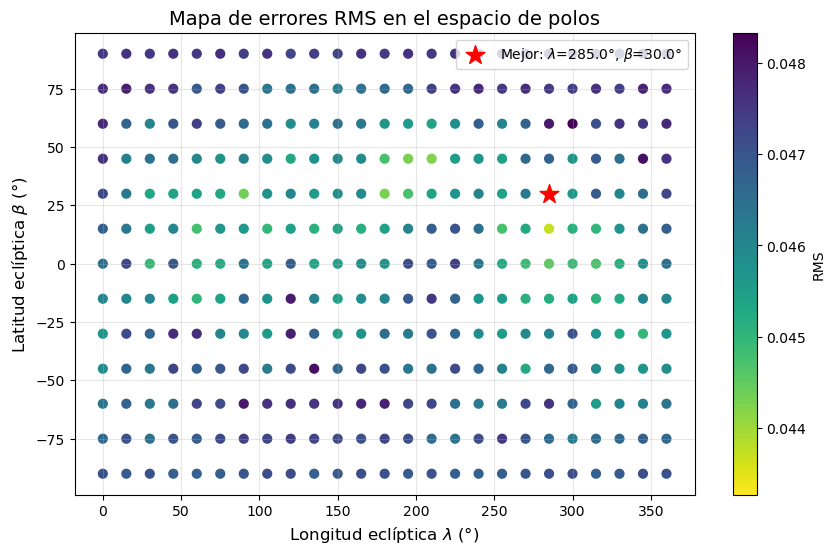


Curvas de luz guardadas en:
C:/Users/HP/Desktop/Maestria/TESIS/DAMIT/version_0.2.1/convexinv/85628\curvas_mejor_solucion.png


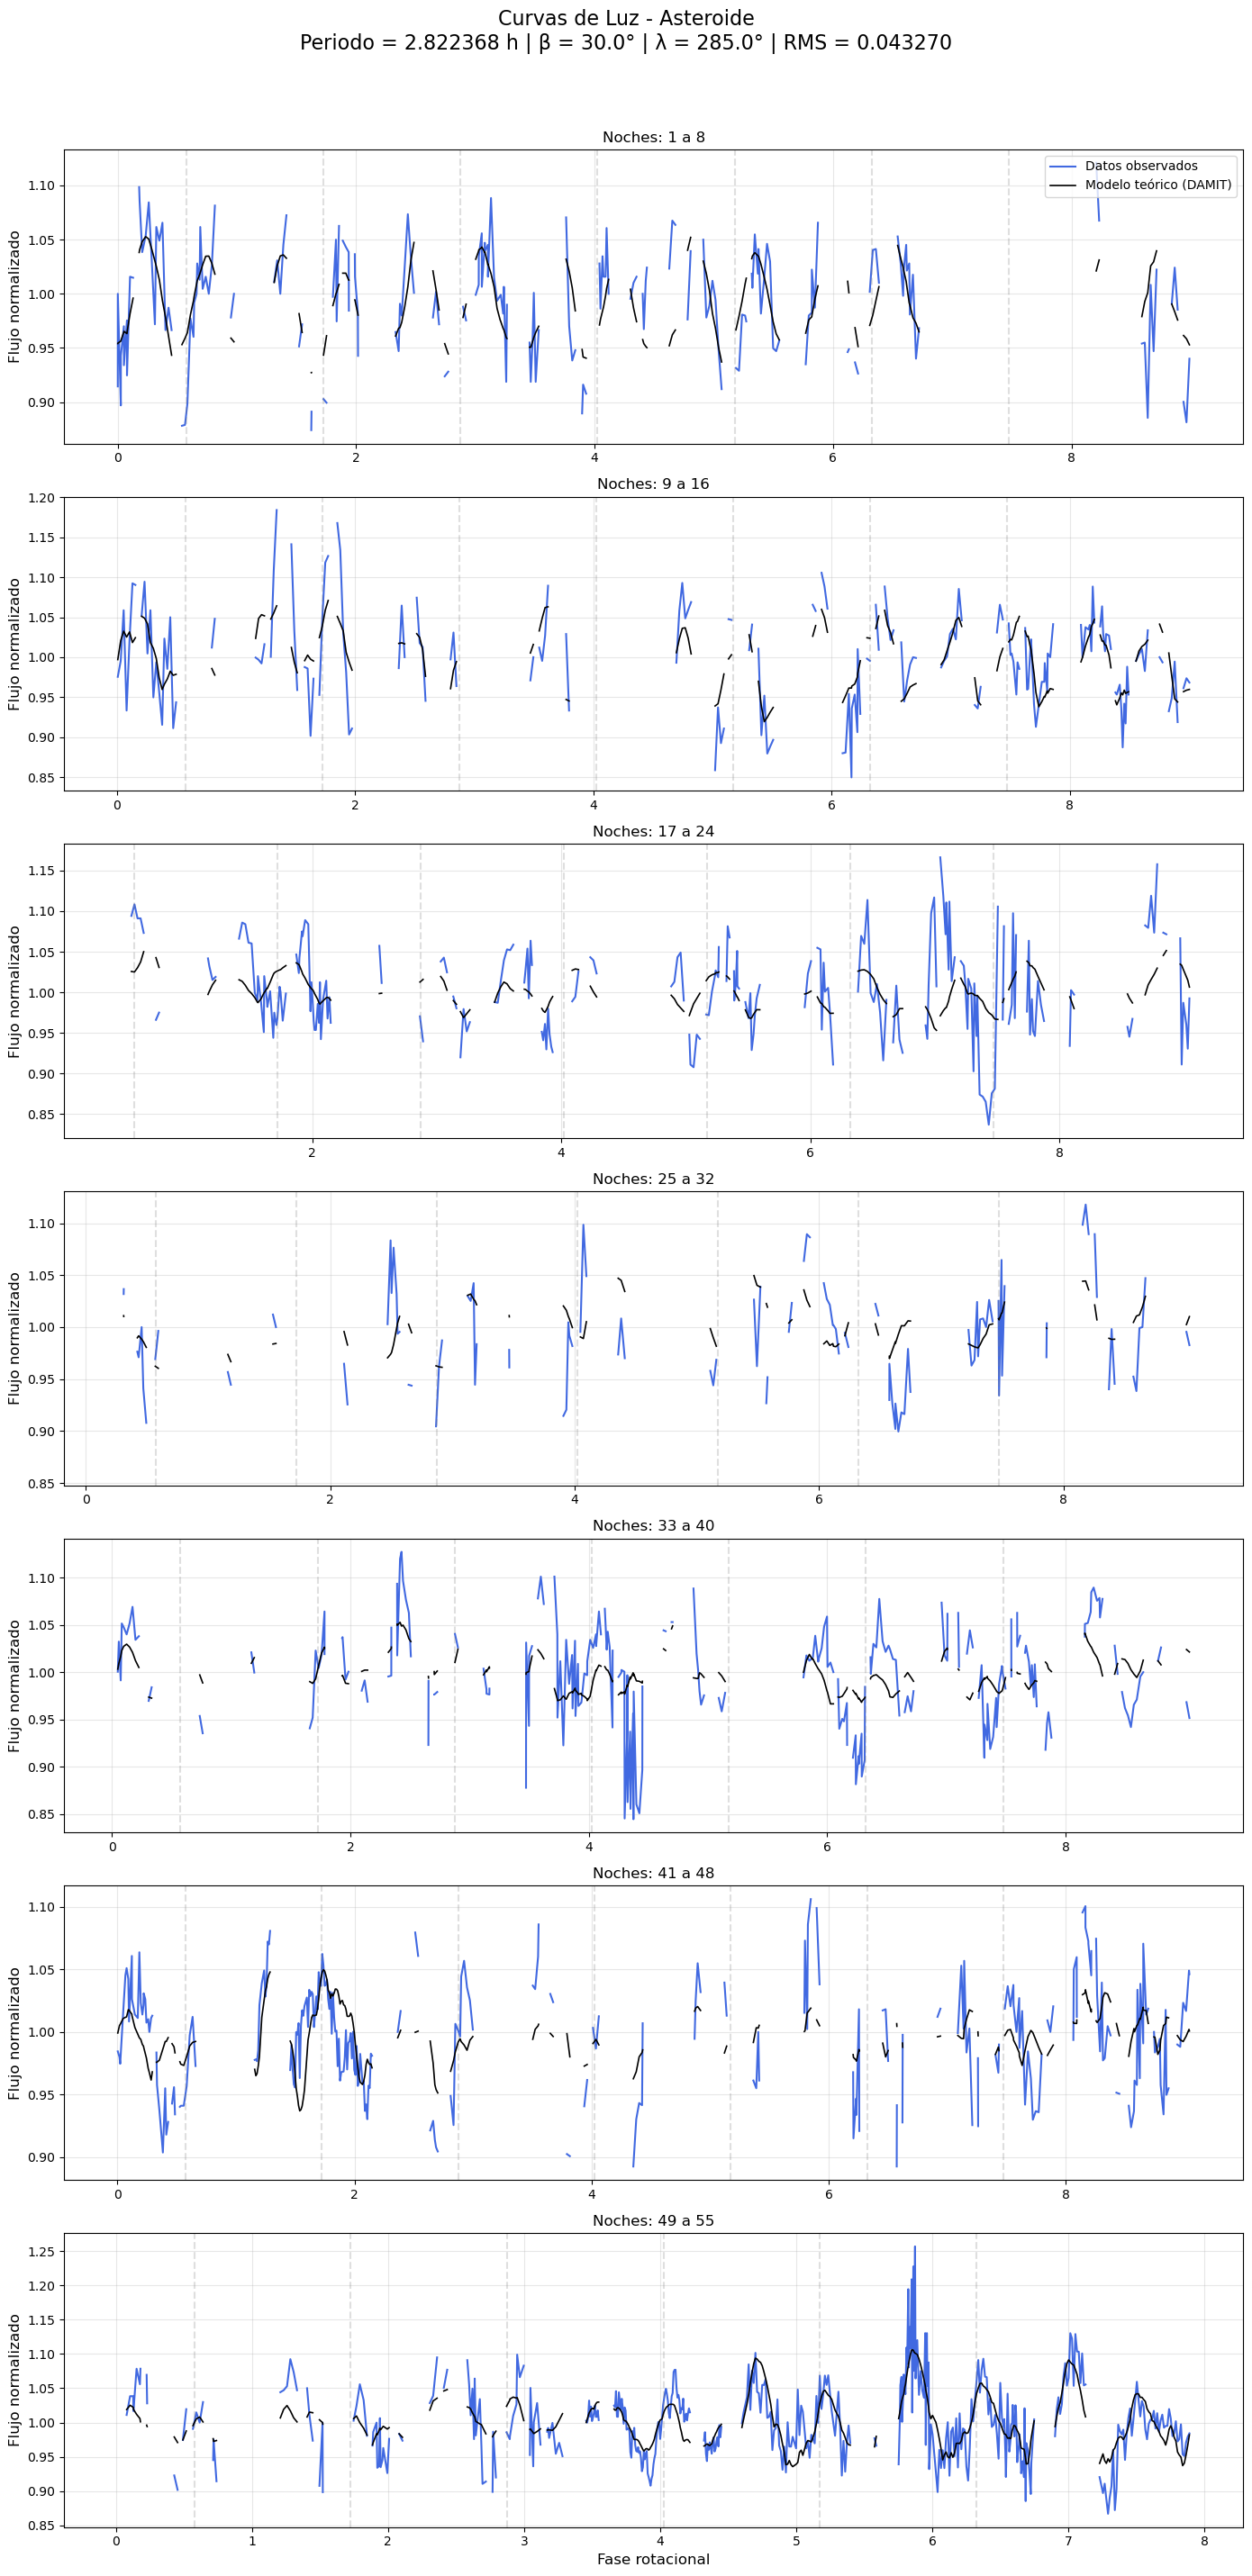

In [9]:
# ============================================================
# ANÁLISIS DE SOLUCIONES DAMIT: LAMBDA - BETA
# ============================================================


carpeta_damit = r"C:/Users/HP/Desktop/Maestria/TESIS/DAMIT/version_0.2.1/convexinv/85628"
archivo_datos = os.path.join(carpeta_damit, "D85628.txt")
archivos_modelo = sorted(glob.glob(os.path.join(carpeta_damit, "out_lcs_*")))
periodo_horas = float(input("Introduce el período rotacional del asteroide [horas]: "))
periodo_dias = periodo_horas / 24.0


desplazamiento_noche = 1.15
noches_por_subplot = 8
umbral_hueco = 0.03


bloques_obs = []
with open(archivo_datos, "r") as f:
    lineas = f.readlines()
i = 0
while i < len(lineas):
    linea = lineas[i].strip()
    if not linea:
        i += 1
        continue
    partes = linea.split()
    if len(partes) >= 2 and partes[0].isdigit() and partes[1].isdigit():
        num_puntos = int(partes[0])
        bloque = []
        i += 1
        for _ in range(num_puntos):
            if i >= len(lineas):
                break
            partes_dato = lineas[i].strip().split()
            if len(partes_dato) >= 2:
                try:
                    jd = float(partes_dato[0])
                    flujo = float(partes_dato[1])
                    bloque.append((jd, flujo))
                except ValueError:
                    pass
            i += 1
        if len(bloque) == num_puntos:
            bloques_obs.append(bloque)
    else:
        i += 1

if len(bloques_obs) == 0:
    raise ValueError("No se encontraron bloques de observaciones en el archivo de datos.")

T0 = bloques_obs[0][0][0]

# ============================================================
# FUNCIONES
# ============================================================

def leer_modelo(archivo):
    with open(archivo, "r") as f:
        valores = [float(linea.strip()) for linea in f if linea.strip()]
    return np.array(valores)

def extraer_beta_lambda(archivo):
    nombre = os.path.basename(archivo)
    patron = r"out_lcs_(-?\d+(?:\.\d+)?)_(-?\d+(?:\.\d+)?)"
    coincidencia = re.search(patron, nombre)
    if coincidencia is None:
        return None, None
    beta = float(coincidencia.group(1))
    lam = float(coincidencia.group(2))
    return beta, lam

def preparar_bloques_base(bloques, modelo=None):
    fases_total = []
    obs_total = []
    mod_total = []
    idx = 0
    for bloque in bloques:
        jds = np.array([p[0] for p in bloque])
        obs = np.array([p[1] for p in bloque])
        fases = ((jds - T0) / periodo_dias) % 1.0
        obs_norm = obs / np.median(obs)
        fases_total.extend(fases)
        obs_total.extend(obs_norm)
        if modelo is not None:
            n = len(bloque)
            if idx + n > len(modelo):
                return None, None, None
            mod = np.array(modelo[idx:idx + n])
            mod_norm = mod / np.median(obs)
            mod_total.extend(mod_norm)
            idx += n
    if modelo is not None:
        return np.array(fases_total), np.array(obs_total), np.array(mod_total)
    else:
        return np.array(fases_total), np.array(obs_total)

def romper_linea_en_huecos(x, y, umbral=0.03):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) == 0:
        return x, y
    x_nuevo = [x[0]]
    y_nuevo = [y[0]]
    for i in range(1, len(x)):
        diferencia = x[i] - x[i - 1]
        if diferencia > umbral:
            x_nuevo.append(np.nan)
            y_nuevo.append(np.nan)
        x_nuevo.append(x[i])
        y_nuevo.append(y[i])
    return np.array(x_nuevo), np.array(y_nuevo)

if len(archivos_modelo) == 0:
    raise ValueError("No se encontraron archivos out_lcs.")

# ============================================================
# EVALUAR TODAS LAS SOLUCIONES
# ============================================================

errores_modelos = []
datos_modelos = []

for archivo in archivos_modelo:
    beta, lam = extraer_beta_lambda(archivo)
    if beta is None:
        continue
    try:
        flujos_modelo = leer_modelo(archivo)
    except Exception:
        continue
    fases, obs_total, mod_total = preparar_bloques_base(bloques_obs, flujos_modelo)
    if fases is None:
        continue
    mse = mean_squared_error(obs_total, mod_total)
    rms = np.sqrt(mse)
    errores_modelos.append((archivo, beta, lam, rms))
    datos_modelos.append((archivo, beta, lam, rms, fases, obs_total, mod_total))

if len(errores_modelos) == 0:
    raise ValueError("No se pudo evaluar ningún modelo.")

errores_modelos.sort(key=lambda x: x[3])

mejor_archivo = errores_modelos[0][0]
mejor_beta = errores_modelos[0][1]
mejor_lambda = errores_modelos[0][2]
mejor_rms = errores_modelos[0][3]

# ============================================================
# MOSTRAR RESULTADOS EN CONSOLA
# ============================================================

print("\n" + "=" * 65)
print("                       MEJOR SOLUCIÓN")
print("=" * 65)
print(f"Archivo : {os.path.basename(mejor_archivo)}")
print(f"Beta    : {mejor_beta:.1f}°")
print(f"Lambda  : {mejor_lambda:.1f}°")
print(f"RMS     : {mejor_rms:.8f}")
print("=" * 65)

print("\n" + "=" * 65)
print("             20 MEJORES SOLUCIONES")
print("=" * 65)
print(f"{'N':>3} {'Beta':>10} {'Lambda':>10} {'RMS':>15}")
print("-" * 65)
for n, (archivo, beta, lam, rms) in enumerate(errores_modelos[:20], start=1):
    print(f"{n:3d} {beta:10.1f} {lam:10.1f} {rms:15.8f}")
print("=" * 65)

# ============================================================
# GRÁFICA 1: MAPA DE RMS (LAMBDA VS BETA)
# ============================================================

lams = [item[2] for item in errores_modelos]
betas = [item[1] for item in errores_modelos]
rmss = [item[3] for item in errores_modelos]

plt.figure(figsize=(10, 6))
sc = plt.scatter(lams, betas, c=rmss, cmap="viridis_r", s=40)
plt.colorbar(sc, label="RMS")
plt.scatter([mejor_lambda], [mejor_beta], color="red", marker="*", s=200, label=f"Mejor: $\\lambda$={mejor_lambda}°, $\\beta$={mejor_beta}°")
plt.xlabel("Longitud eclíptica $\\lambda$ (°)", fontsize=12)
plt.ylabel("Latitud eclíptica $\\beta$ (°)", fontsize=12)
plt.title("Mapa de errores RMS en el espacio de polos", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
ruta_mapa = os.path.join(carpeta_damit, "mapa_rms_polos.png")
plt.savefig(ruta_mapa, dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# GRAFICAR MEJOR SOLUCIÒN
# ============================================================

fases_mejor = None
obs_mejor = None
mod_mejor = None

for archivo, beta, lam, rms, fases, obs_total, mod_total in datos_modelos:
    if archivo == mejor_archivo:
        fases_mejor = fases
        obs_mejor = obs_total
        mod_mejor = mod_total
        break

if fases_mejor is None:
    raise ValueError("No se pudieron recuperar los datos de la mejor solución.")

total_noches = len(bloques_obs)
num_subplots = math.ceil(total_noches / noches_por_subplot)
fig, axes = plt.subplots(num_subplots, 1, figsize=(14, 4 * num_subplots))
if num_subplots == 1:
    axes = [axes]

fig.suptitle(
    f"Curvas de Luz - Asteroide\n"
    f"Periodo = {periodo_horas:.6f} h | "
    f"β = {mejor_beta:.1f}° | "
    f"λ = {mejor_lambda:.1f}° | "
    f"RMS = {mejor_rms:.6f}",
    fontsize=16,
    y=1.02
)

idx_global = 0

for i_subplot in range(num_subplots):
    ax = axes[i_subplot]
    noche_inicio = i_subplot * noches_por_subplot
    noche_fin = min(noche_inicio + noches_por_subplot, total_noches)
    fases_linea_modelo = []
    mod_linea_modelo = []
    for idx_local, i_bloque in enumerate(range(noche_inicio, noche_fin)):
        bloque = bloques_obs[i_bloque]
        n = len(bloque)
        fases_bloque = fases_mejor[idx_global:idx_global + n]
        obs_bloque = obs_mejor[idx_global:idx_global + n]
        mod_bloque = mod_mejor[idx_global:idx_global + n]
        orden = np.argsort(fases_bloque)
        fases_ordenadas = fases_bloque[orden]
        obs_ordenadas = obs_bloque[orden]
        mod_ordenadas = mod_bloque[orden]
        fases_desplazadas = fases_ordenadas + (idx_local * desplazamiento_noche)
        fases_obs_plot, obs_plot = romper_linea_en_huecos(fases_desplazadas, obs_ordenadas, umbral=umbral_hueco)
        etiqueta_obs = "Datos observados" if (idx_local == 0 and i_subplot == 0) else ""
        ax.plot(
            fases_obs_plot,
            obs_plot,
            linewidth=1.5,
            color="royalblue",
            label=etiqueta_obs
        )
        if idx_local > 0:
            fases_linea_modelo.append(np.nan)
            mod_linea_modelo.append(np.nan)
        fases_linea_modelo.extend(fases_desplazadas)
        mod_linea_modelo.extend(mod_ordenadas)
        if idx_local > 0:
            ax.axvline(
                idx_local * desplazamiento_noche - (desplazamiento_noche / 2),
                color="gray",
                linestyle="--",
                alpha=0.25
            )
        idx_global += n

    etiqueta_mod = "Modelo teórico (DAMIT)" if i_subplot == 0 else ""
    fases_modelo_plot, mod_modelo_plot = romper_linea_en_huecos(
        np.array(fases_linea_modelo),
        np.array(mod_linea_modelo),
        umbral=umbral_hueco
    )
    ax.plot(
        fases_modelo_plot,
        mod_modelo_plot,
        color="black",
        linewidth=1.2,
        label=etiqueta_mod
    )
    ax.set_title(f"Noches: {noche_inicio + 1} a {noche_fin}", fontsize=12)
    ax.set_ylabel("Flujo normalizado", fontsize=12)
    ax.grid(alpha=0.3)
    if i_subplot == 0:
        ax.legend()
    if i_subplot == num_subplots - 1:
        ax.set_xlabel("Fase rotacional", fontsize=12)

plt.tight_layout()
ruta_curvas = os.path.join(carpeta_damit, "curvas_mejor_solucion.png")
plt.savefig(ruta_curvas, dpi=300, bbox_inches="tight")
print(f"\nCurvas de luz guardadas en:\n{ruta_curvas}")
plt.show()

In [7]:
################################
# GRÁFICAR LA FORMA
################################

filename = "C:/Users/HP/Desktop/Maestria/TESIS/DAMIT/version_0.2.1/convexinv/model66146"

nombre_asteroide = input("Introduce el nombre o número del asteroide: ")
lambda_deg = float(input("Introduce el valor de λ (Lambda) en grados: "))
beta_deg = float(input("Introduce el valor de β (Beta) en grados: "))


fase_rotacional = 0.25
rotacion_deg = 360.0 * fase_rotacional


def read_model_file(filename):
    with open(filename, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    npts, nfac = map(int, lines[0].split())
    
    vertices = np.array([
        list(map(float, lines[i + 1].split()))
        for i in range(npts)
    ])
    
    faces = []
    for line in lines[npts + 1:]:
        indices = list(map(int, line.split()))
        if len(indices) >= 3:
            faces.append([i - 1 for i in indices])
    
    return vertices, faces



def spin_vector(lambda_deg, beta_deg):
    lam = np.radians(lambda_deg)
    bet = np.radians(beta_deg)
    x = np.cos(bet) * np.cos(lam)
    y = np.cos(bet) * np.sin(lam)
    z = np.sin(bet)
    return np.array([x, y, z])



def rotation_matrix(axis, theta_deg):
    theta = np.radians(theta_deg)
    axis = axis / np.linalg.norm(axis)
    x, y, z = axis
    c = np.cos(theta)
    s = np.sin(theta)
    R = np.array([
        [c + x*x*(1-c), x*y*(1-c) - z*s, x*z*(1-c) + y*s],
        [y*x*(1-c) + z*s, c + y*y*(1-c), y*z*(1-c) - x*s],
        [z*x*(1-c) - y*s, z*y*(1-c) + x*s, c + z*z*(1-c)]
    ])
    return R



vertices, faces = read_model_file(filename)
spin = spin_vector(lambda_deg, beta_deg)
R = rotation_matrix(spin, rotacion_deg)
vertices_rot = vertices @ R.T


x = vertices_rot[:, 0]
y = vertices_rot[:, 1]
z = vertices_rot[:, 2]



i, j, k = [], [], []
for face in faces:
    for t in range(1, len(face) - 1):
        i.append(face[0])
        j.append(face[t])
        k.append(face[t + 1])


edge_x, edge_y, edge_z = [], [], []
for face in faces:
    n = len(face)
    for m in range(n):
        p1 = vertices_rot[face[m]]
        p2 = vertices_rot[face[(m + 1) % n]]
        edge_x.extend([p1[0], p2[0], None])
        edge_y.extend([p1[1], p2[1], None])
        edge_z.extend([p1[2], p2[2], None])


tam = np.max(np.abs(vertices_rot))

tam_spin = tam * 2.0
x_line = [-spin[0] * tam_spin, spin[0] * tam_spin]
y_line = [-spin[1] * tam_spin, spin[1] * tam_spin]
z_line = [-spin[2] * tam_spin, spin[2] * tam_spin]

cone_x = [spin[0] * tam_spin]
cone_y = [spin[1] * tam_spin]
cone_z = [spin[2] * tam_spin]
u = [spin[0]]
v = [spin[1]]
w = [spin[2]]


fig = go.Figure()


fig.add_trace(go.Mesh3d(
    x=x, y=y, z=z,
    i=i, j=j, k=k,
    color='lightgray',
    opacity=1.0,
    flatshading=True,
    lighting=dict(ambient=0.5, diffuse=0.8, specular=0.2),
    showscale=False,
    showlegend=False
))



fig.add_trace(go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines',
    line=dict(color='black', width=1),
    showlegend=False
))



fig.add_trace(go.Scatter3d(
    x=x_line, y=y_line, z=z_line,
    mode='lines',
    line=dict(color='red', width=6),
    showlegend=False
))


fig.add_trace(go.Cone(
    x=cone_x, y=cone_y, z=cone_z,
    u=u, v=v, w=w,
    sizemode="absolute",
    sizeref=tam * 0.12,
    showscale=False,
    colorscale=[[0, 'red'], [1, 'red']],
    showlegend=False
))


fig.add_annotation(
    text=(f"<b>Asteroide:</b> {nombre_asteroide}<br>λ = {lambda_deg:.1f}°<br>β = {beta_deg:.1f}°"),
    align='left',
    showarrow=False,
    xref='paper', yref='paper',
    x=0.04, y=0.96,
    bordercolor='gray',
    borderwidth=1,
    borderpad=8,
    bgcolor='rgba(255,255,255,0.85)',
    font=dict(size=18, family='Arial', color='black')
)


camera = dict(eye=dict(x=2.2, y=2.2, z=1.5))

fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False, showgrid=False, zeroline=False),
        yaxis=dict(visible=False, showgrid=False, zeroline=False),
        zaxis=dict(visible=False, showgrid=False, zeroline=False),
        aspectmode='data',
        bgcolor='white',
        camera=camera
    ),
    width=900,
    height=800,
    margin=dict(l=10, r=10, b=10, t=10),
    paper_bgcolor='white'
)



plot_id = "plotly_" + uuid.uuid4().hex


html = fig.to_html(
    full_html=False,
    include_plotlyjs='cdn',
    div_id=plot_id
)


javascript = f"""
<script>
(function(){{
    var gd = document.getElementById('{plot_id}');
    if (!gd) {{
        console.log('No se encontró la figura Plotly.');
        return;
    }}
    var indicator = document.createElement('div');
    indicator.id = '{plot_id}_indicator';
    indicator.style.position = 'absolute';
    indicator.style.right = '25px';
    indicator.style.top = '25px';
    indicator.style.width = '190px';
    indicator.style.height = '190px';
    indicator.style.background = 'rgba(255,255,255,0.94)';
    indicator.style.border = '1px solid #777';
    indicator.style.borderRadius = '5px';
    indicator.style.zIndex = '9999';
    indicator.style.pointerEvents = 'none';
    indicator.style.fontFamily = 'Arial';
    gd.parentElement.style.position = 'relative';
    gd.parentElement.appendChild(indicator);
    indicator.innerHTML = `
        <svg width="190" height="190" viewBox="0 0 190 190">
            <text x="95" y="20" text-anchor="middle" font-size="13" font-family="Arial" font-weight="bold" fill="black">Sistema de referencia</text>
            <line id="{plot_id}_axis_x" x1="95" y1="100" x2="145" y2="100" stroke="red" stroke-width="3"/>
            <polygon id="{plot_id}_arrow_x" points="145,100 136,95 136,105" fill="red"/>
            <text id="{plot_id}_label_x" x="150" y="105" font-size="15" font-weight="bold" fill="red">+X</text>
            <line id="{plot_id}_axis_y" x1="95" y1="100" x2="95" y2="50" stroke="green" stroke-width="3"/>
            <polygon id="{plot_id}_arrow_y" points="95,50 90,59 100,59" fill="green"/>
            <text id="{plot_id}_label_y" x="95" y="43" text-anchor="middle" font-size="15" font-weight="bold" fill="green">+Y</text>
            <line id="{plot_id}_axis_z" x1="95" y1="100" x2="65" y2="135" stroke="blue" stroke-width="3"/>
            <polygon id="{plot_id}_arrow_z" points="65,135 75,133 68,126" fill="blue"/>
            <text id="{plot_id}_label_z" x="52" y="145" font-size="15" font-weight="bold" fill="blue">+Z</text>
            <circle cx="95" cy="100" r="4" fill="black"/>
        </svg>
    `;
    function dot(a, b) {{
        return a[0] * b[0] + a[1] * b[1] + a[2] * b[2];
    }}
    function norm(a) {{
        return Math.sqrt(dot(a, a));
    }}
    function normalize(a) {{
        var n = norm(a);
        return [a[0] / n, a[1] / n, a[2] / n];
    }}
    function cross(a, b) {{
        return [
            a[1] * b[2] - a[2] * b[1],
            a[2] * b[0] - a[0] * b[2],
            a[0] * b[1] - a[1] * b[0]
        ];
    }}
    function actualizarEje(axis, line, arrow, label, color, nombre, right, up) {{
        var px = dot(axis, right);
        var py = dot(axis, up);
        var sx = px * 55;
        var sy = -py * 55;
        var x1 = 95;
        var y1 = 100;
        var x2 = 95 + sx;
        var y2 = 100 + sy;
        line.setAttribute('x2', x2);
        line.setAttribute('y2', y2);
        var dx = x2 - x1;
        var dy = y2 - y1;
        var length = Math.sqrt(dx * dx + dy * dy);
        if (length < 1) {{
            length = 1;
        }}
        dx /= length;
        dy /= length;
        var px2 = -dy;
        var py2 = dx;
        var arrowLength = 10;
        var arrowWidth = 5;
        var bx = x2 - dx * arrowLength;
        var by = y2 - dy * arrowLength;
        var p1x = bx + px2 * arrowWidth;
        var p1y = by + py2 * arrowWidth;
        var p2x = bx - px2 * arrowWidth;
        var p2y = by - py2 * arrowWidth;
        arrow.setAttribute('points', x2 + ',' + y2 + ' ' + p1x + ',' + p1y + ' ' + p2x + ',' + p2y);
        var sign;
        if (Math.abs(px) >= Math.abs(py)) {{
            sign = px >= 0 ? '+' : '-';
        }} else {{
            sign = py >= 0 ? '+' : '-';
        }}
        var labelDistance = 10;
        var lx = x2 + dx * labelDistance;
        var ly = y2 + dy * labelDistance;
        label.setAttribute('x', lx);
        label.setAttribute('y', ly);
        label.textContent = sign + nombre;
    }}
    function actualizarIndicador() {{
        if (!gd.layout || !gd.layout.scene || !gd.layout.scene.camera) {{
            return;
        }}
        var eye = gd.layout.scene.camera.eye;
        var cameraVector = normalize([eye.x, eye.y, eye.z]);
        var view = [-cameraVector[0], -cameraVector[1], -cameraVector[2]];
        var upReference = [0, 0, 1];
        if (Math.abs(dot(view, upReference)) > 0.95) {{
            upReference = [0, 1, 0];
        }}
        var right = normalize(cross(view, upReference));
        var up = normalize(cross(right, view));
        var X = [1, 0, 0];
        var Y = [0, 1, 0];
        var Z = [0, 0, 1];
        var lineX = document.getElementById('{plot_id}_axis_x');
        var arrowX = document.getElementById('{plot_id}_arrow_x');
        var labelX = document.getElementById('{plot_id}_label_x');
        var lineY = document.getElementById('{plot_id}_axis_y');
        var arrowY = document.getElementById('{plot_id}_arrow_y');
        var labelY = document.getElementById('{plot_id}_label_y');
        var lineZ = document.getElementById('{plot_id}_axis_z');
        var arrowZ = document.getElementById('{plot_id}_arrow_z');
        var labelZ = document.getElementById('{plot_id}_label_z');
        actualizarEje(X, lineX, arrowX, labelX, 'red', 'X', right, up);
        actualizarEje(Y, lineY, arrowY, labelY, 'green', 'Y', right, up);
        actualizarEje(Z, lineZ, arrowZ, labelZ, 'blue', 'Z', right, up);
    }}
    gd.on('plotly_relayout', function(eventData) {{
        setTimeout(actualizarIndicador, 50);
    }});
    setTimeout(actualizarIndicador, 500);
}})();
</script>
"""


display(HTML(html + javascript))

Introduce el nombre o número del asteroide:  66146
Introduce el valor de λ (Lambda) en grados:  90
Introduce el valor de β (Beta) en grados:  45
